In [69]:
import numpy as np
import pandas as pd

In [70]:
try:
    from wordcloud import WordCloud
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud'])
    from wordcloud import WordCloud
print('wordcloud available')


wordcloud available


In [71]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5093,ham,Gokila is talking with you aha:),NaN,NaN,NaN
3405,ham,\HEY DAS COOL... IKNOW ALL 2 WELLDA PERIL OF S...,NaN,NaN,NaN
350,ham,"Nah can't help you there, I've never had an ip...",NaN,NaN,NaN
1770,ham,Dont show yourself. How far. Put new pictures ...,NaN,NaN,NaN
4392,spam,RECPT 1/3. You have ordered a Ringtone. Your o...,NaN,NaN,NaN


In [72]:
df.shape    # check the total number of rows and columns

(5572, 5)

In [73]:
# Steps to build a machine learning project:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Model Evaluation
# 6. Improvements
# 7. Website
# 8. Deployment

# 1. Data Cleaning

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [75]:
# drop last 3 columns as they are not useful for our analysis
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [76]:
df.sample(5)

,v1,v2
645,ham,"Watching cartoon, listening music &amp; at eve..."
1755,ham,Really good:)dhanush rocks once again:)
1891,ham,Probably earlier than that if the station's wh...
2992,ham,So i'm doing a list of buyers.
3012,spam,FREE UNLIMITED HARDCORE PORN direct 2 your mob...


In [77]:
# renaming the columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text
932,ham,So do you have samus shoulders yet
2774,ham,"Dude u knw also telugu..thts gud..k, gud nyt.."
3669,ham,Ok thanx... Take care then...
393,ham,Yes i think so. I am in office but my lap is i...
1167,ham,Lol now I'm after that hot air balloon!


In [78]:
from sklearn.preprocessing import LabelEncoder    # to convert the target column into numerical values
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])  # ham -> 0, spam -> 1
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [79]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [80]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [81]:
# remove duplicates
df = df.drop_duplicates(keep='first')   # keep='first' means that we will keep the first occurrence of the duplicate value and drop the rest
df.duplicated().sum()    # check again for duplicate values

np.int64(0)

In [82]:
df.shape

(5169, 2)

# 2. EDA

In [83]:
# EDA -> Exploratory Data Analysis

In [84]:
# Check how many ham and spam messages are there in the dataset
print(df.head())
print(df['target'].value_counts())


   target                                               text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...
target
0    4516
1     653
Name: count, dtype: int64


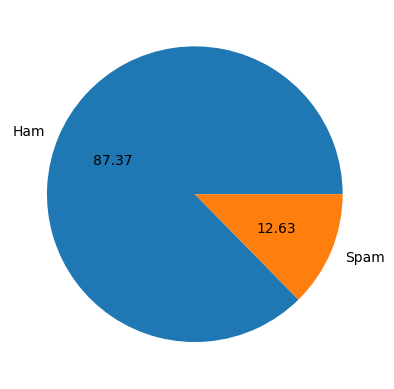

In [85]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['Ham', 'Spam'], autopct='%0.2f')
plt.show()

In [86]:
# Data is imbalanced as there are more ham messages than spam messages. We will handle this imbalance later in the project.

In [87]:
import nltk     # Natural Language Toolkit -> to perform text preprocessing

In [88]:
nltk.download('punkt_tab')   # download the punkt_tab tokenizer for word tokenization

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\somne\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [89]:
df['text']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5169, dtype: str

In [90]:
df['num_characters'] = df['text'].apply(len)   # to calculate the number of characters in each message
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [91]:
# number of words in each message
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))   # to split the text into words and count the number of words in each message
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [92]:
# number of sentences in each message
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))   # to split the text into sentences and count the number of sentences in each message
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [93]:
df[['num_characters', 'num_words', 'num_sentences']].describe()   # to get the statistical summary of the numerical columns

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [94]:
# Ham messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()   # to get the statistical summary of the numerical columns for ham messages

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [95]:
# Spam messages
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()   # to get the statistical summary of the numerical columns for spam messages

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [96]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

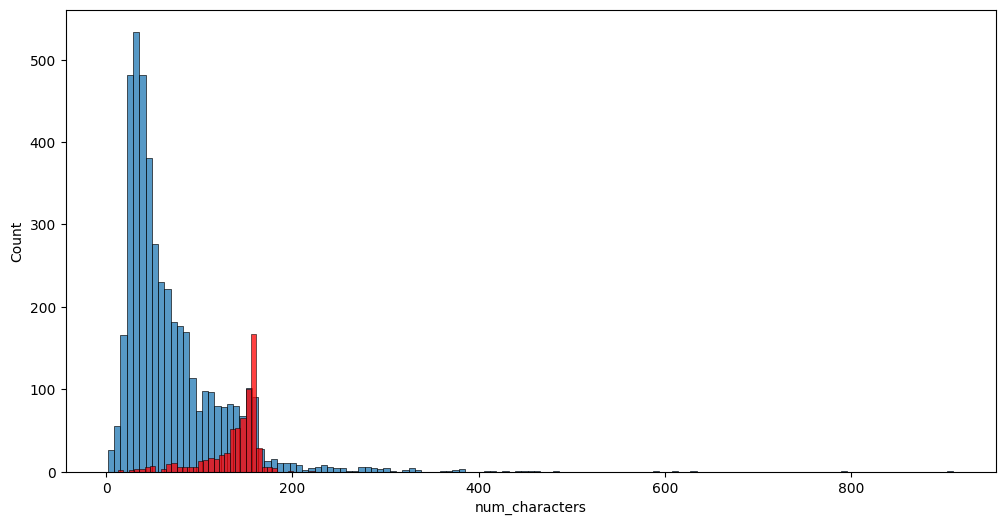

In [97]:
# to plot the distribution of the number of characters in ham and spam messages
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target'] == 0]['num_characters'])   # to plot the distribution of the number of characters in ham messages
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')   # to plot the distribution of the number of characters in spam messages

<Axes: xlabel='num_words', ylabel='Count'>

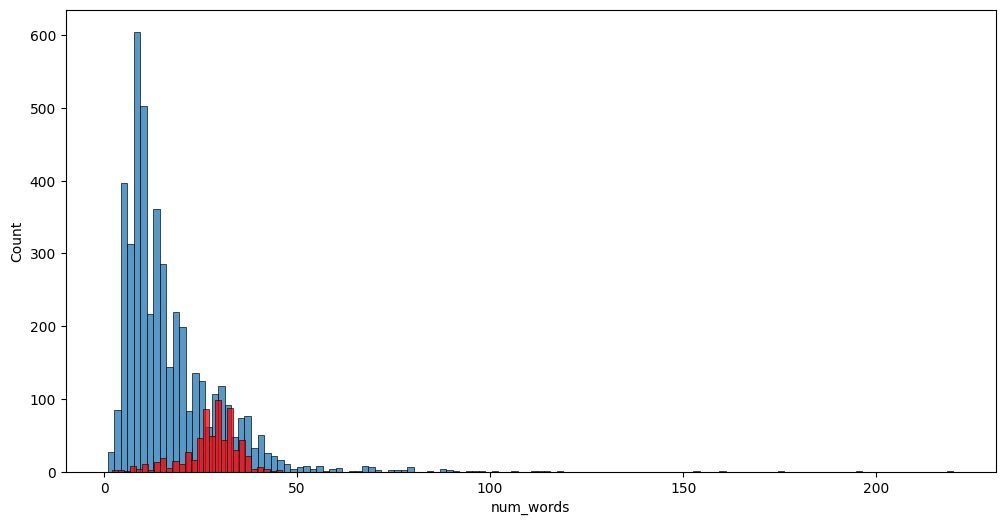

In [98]:
# to plot the distribution of the number of words in ham and spam messages
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target'] == 0]['num_words'])   # to plot the distribution of the number of words in ham messages
sns.histplot(df[df['target'] == 1]['num_words'], color='red')   # to plot the distribution of the number of words in spam messages

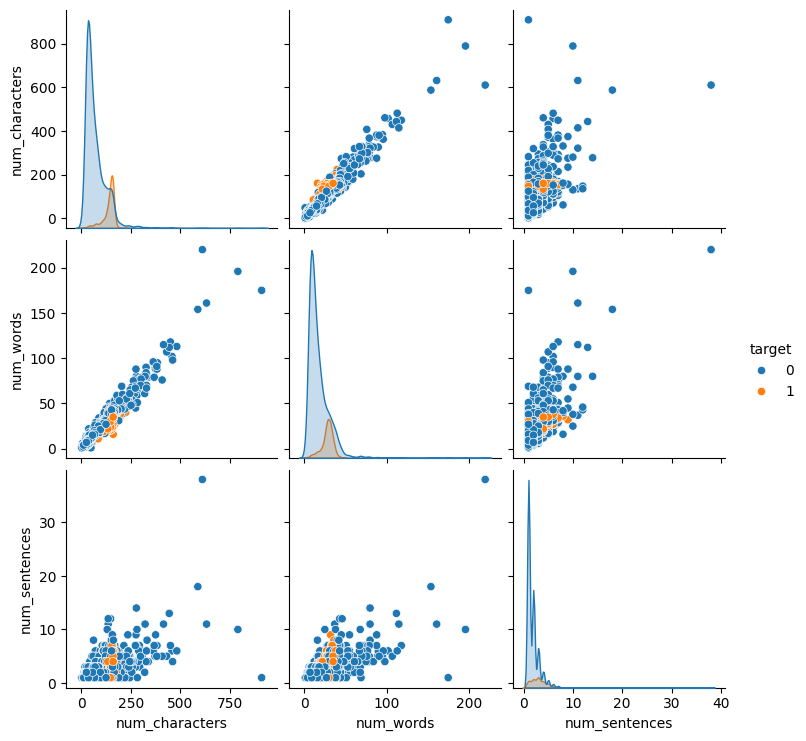

In [99]:
sns.pairplot(df, hue='target')   # to plot the pairplot of the numerical columns with respect to the target column

In [100]:
df.select_dtypes(include='number').corr()   # calculate correlation only for numeric columns


,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

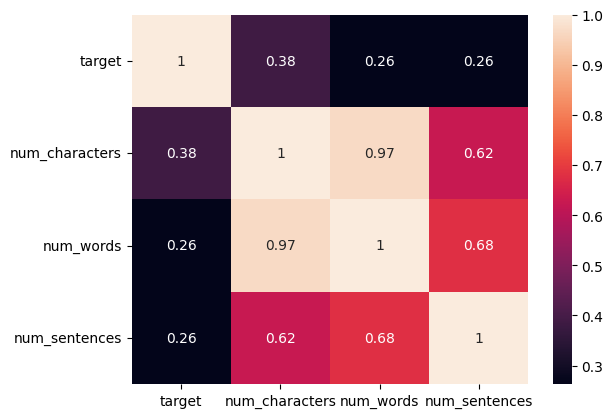

In [101]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)   # to plot the heatmap of the correlation between the numerical columns

# 3. Data Processing
- Lower Case
- Tokenization
- Removing Special Characters
- Removing Stop Words and Punctuation
- Stemming

In [102]:
from nltk.corpus import stopwords
nltk.download('stopwords')   # download the stopwords from nltk
print(stopwords.words('english'))   # to get the list of stopwords in English
import string
print(string.punctuation)   # to get the list of punctuation marks
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()   # to perform stemming on the text data
print(ps.stem('loving'))   # to get the stem of the word 'loving'

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\somne\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [103]:
def transform_text(text):
    text = text.lower()   # convert the text to lowercase
    text = nltk.word_tokenize(text)   # to split the text into words

    y = []
    for i in text:
        if i.isalnum():   # to check if the word is alphanumeric
            y.append(i)
    
    text = y[:]   # to copy the list y to text
    y.clear()   # to clear the list y

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:   # to check if the word is not a stopword and not a punctuation mark
            y.append(i)

    text = y[:]   # to copy the list y to text
    y.clear()   # to clear the list y
    # Perform stemming
    for i in text:
        y.append(ps.stem(i))   # to get the stem of the word and append it to the list y
    
    return " ".join(y)

In [104]:
print(transform_text('Hi Somneel, How are you?'))
print(transform_text('Did you watch the latest episode of Game of Thrones? It was amazing!'))

hi somneel
watch latest episod game throne amaz


In [105]:
df['transformed_text'] = df['text'].apply(transform_text)

In [106]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [107]:
# we will make word clouds for ham and spam messages to visualize the most common words in ham and spam messages., word clouds are a visual representation of the most common words in a text data, where the size of each word represents its frequency in the text data. We will use the WordCloud library to create word clouds for ham and spam messages.
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')   # to create a WordCloud object with specified width, height, minimum font size and background color

In [108]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))   # to generate the word cloud for spam messages by concatenating all the transformed text of spam messages and passing it to the generate method of the WordCloud object

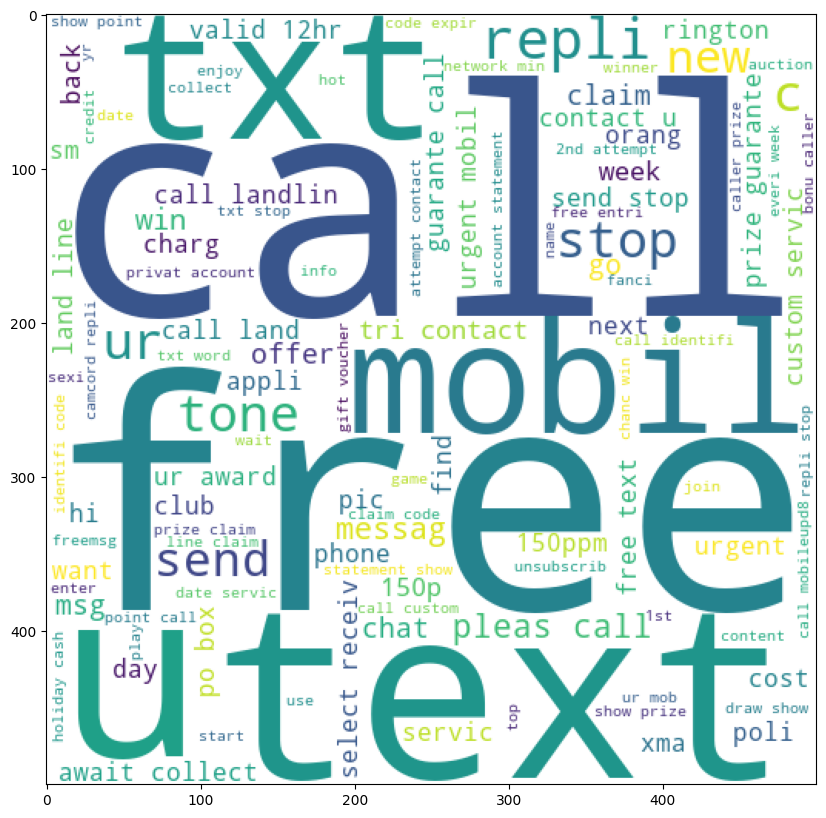

In [109]:
plt.figure(figsize=(15, 10))
plt.imshow(spam_wc)   # to display the word cloud for spam messages

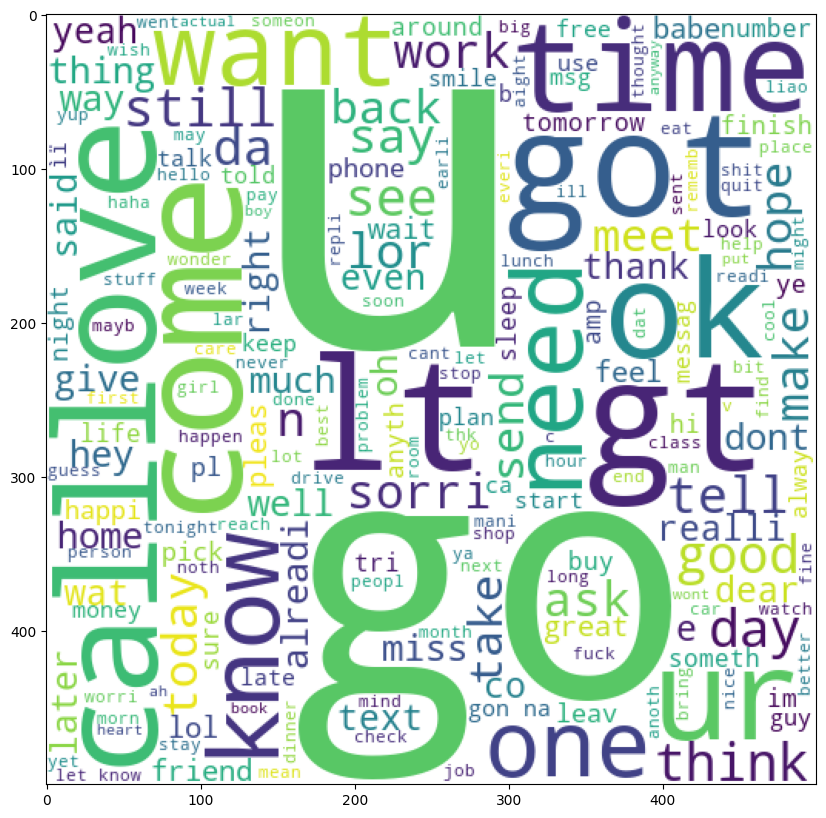

In [110]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))   # to generate the word cloud for ham messages by concatenating all the transformed text of ham messages and passing it to the generate method of the WordCloud object
plt.figure(figsize=(15, 10))
plt.imshow(ham_wc)   # to display the word cloud for ham messages

In [111]:
# Take out top 30 words in ham and spam messages
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():      # to get the list of transformed text of spam messages and iterate through each message
    for word in msg.split():                                        # to split each message into words and iterate through each word
        spam_corpus.append(word)                                    # to append each word to the list spam_corpus

print(spam_corpus)
print(len(spam_corpus))   # to get the total number of words in the spam corpus

['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', '21st', 'may', 'text', 'fa', '87121', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli', '08452810075over18', 'freemsg', 'hey', 'darl', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chg', 'send', 'rcv', 'winner', 'valu', 'network', 'custom', 'select', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hour', 'mobil', '11', 'month', 'u', 'r', 'entitl', 'updat', 'latest', 'colour', 'mobil', 'camera', 'free', 'call', 'mobil', 'updat', 'co', 'free', '08002986030', 'six', 'chanc', 'win', 'cash', '100', 'pound', 'txt', 'csh11', 'send', 'cost', '6day', 'tsandc', 'appli', 'repli', 'hl', '4', 'info', 'urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18', 'xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'click',

In [112]:
from collections import Counter
Counter(spam_corpus).most_common(30)   # to get the top 30 most common words in the spam corpus and their counts

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

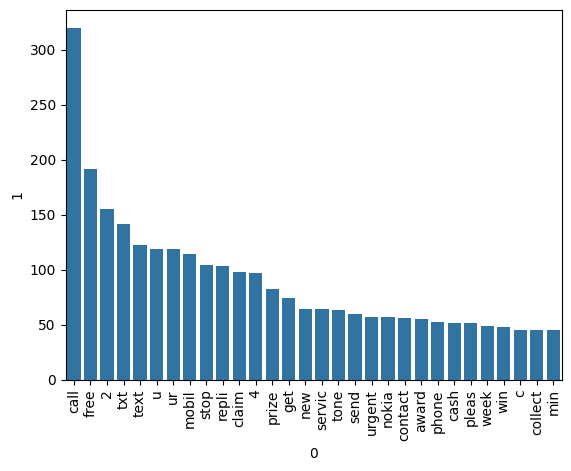

In [113]:
top_30_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))   # to create a DataFrame of the top 30 most common words in the spam corpus and their counts
sns.barplot(x=top_30_spam[0], y=top_30_spam[1])
plt.xticks(rotation='vertical')   # to rotate the x-axis labels vertically
plt.show()

['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'wat', 'ok', 'lar', 'joke', 'wif', 'u', 'oni', 'u', 'dun', 'say', 'earli', 'hor', 'u', 'c', 'alreadi', 'say', 'nah', 'think', 'goe', 'usf', 'live', 'around', 'though', 'even', 'brother', 'like', 'speak', 'treat', 'like', 'aid', 'patent', 'per', 'request', 'mell', 'oru', 'minnaminungint', 'nurungu', 'vettam', 'set', 'callertun', 'caller', 'press', '9', 'copi', 'friend', 'callertun', 'gon', 'na', 'home', 'soon', 'want', 'talk', 'stuff', 'anymor', 'tonight', 'k', 'cri', 'enough', 'today', 'search', 'right', 'word', 'thank', 'breather', 'promis', 'wont', 'take', 'help', 'grant', 'fulfil', 'promis', 'wonder', 'bless', 'time', 'date', 'sunday', 'oh', 'k', 'watch', 'eh', 'u', 'rememb', '2', 'spell', 'name', 'ye', 'v', 'naughti', 'make', 'v', 'wet', 'fine', 'thatåõ', 'way', 'u', 'feel', 'thatåõ', 'way', 'gota', 'b', 'serious', 'spell', 'name', 'go', 'tri', '2', 'month', 'ha', 

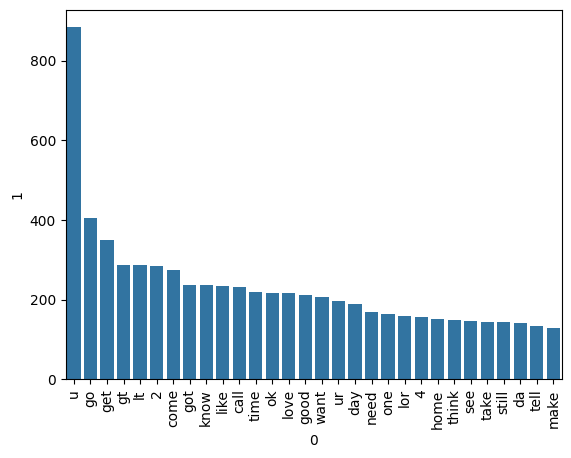

In [114]:
# Take out top 30 words in ham and spam messages
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():      # to get the list of transformed text of ham messages and iterate through each message
    for word in msg.split():                                        # to split each message into words and iterate through each word
        ham_corpus.append(word)                                     # to append each word to the list ham_corpus

print(ham_corpus)
print(len(ham_corpus))   # to get the total number of words in the ham corpus

top_30_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))   # to create a DataFrame of the top 30 most common words in the ham corpus and their counts
sns.barplot(x=top_30_ham[0], y=top_30_ham[1])
plt.xticks(rotation='vertical')   # to rotate the x-axis labels vertically
plt.show()

# 4. Model Building

In [115]:
# In textual data, naive bayes algorithm is the best algorithm to use for text classification problems. We will use the Multinomial, Bernoulli and Gaussian Naive Bayes algorithm for our SMS spam detection project.
from sklearn.feature_extraction.text import CountVectorizer     # Countvector implements the bag of words model to convert the text data into a matrix of token counts
cv = CountVectorizer()   # to create a CountVectorizer object to convert the text data into a matrix of token counts
X = cv.fit_transform(df['transformed_text']).toarray()   # to fit the CountVectorizer object on the transformed text data and convert it into a matrix of token counts
print(X)
print(X.shape)   # to get the shape of the matrix of token counts

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(5169, 6708)


In [ ]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [116]:
y = df['target'].values   # to get the target variable as a numpy array
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)   # to split the data into training and testing sets with a test size of 20% and a random state of 2 for reproducibility

In [118]:
from sklearn.naive_bayes import MultinomialNB,BernoulliNB,GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score
gnb = GaussianNB()   # to create a Gaussian Naive Bayes model
mnb = MultinomialNB()   # to create a Multinomial Naive Bayes model
bnb = BernoulliNB()   # to create a Bernoulli Naive Bayes model

In [119]:
gnb.fit(X_train, y_train)   # to fit the Gaussian Naive Bayes model on the training data
y_pred_gnb = gnb.predict(X_test)   # to predict the target variable for the test data using the Gaussian Naive Bayes model
print(accuracy_score(y_test, y_pred_gnb))   # to calculate the accuracy of the Gaussian Naive Bayes model on the test data
print("*"*60)
print(confusion_matrix(y_test, y_pred_gnb))   # to calculate the confusion matrix for the Gaussian Naive Bayes model on the test data
print("*"*60)
print(precision_score(y_test, y_pred_gnb))   # to calculate the precision score for the Gaussian Naive Bayes model on the test data

0.8800773694390716
************************************************************
[[792 104]
 [ 20 118]]
************************************************************
0.5315315315315315


In [120]:
mnb.fit(X_train, y_train)   # to fit the Multinomial Naive Bayes model on the training data
y_pred_mnb = mnb.predict(X_test)   # to predict the target variable for the test data using the Multinomial Naive Bayes model
print(accuracy_score(y_test, y_pred_mnb))   # to calculate the accuracy of the Multinomial Naive Bayes model on the test data
print("*"*60)
print(confusion_matrix(y_test, y_pred_mnb))   # to calculate the confusion matrix for the Multinomial Naive Bayes model on the test data
print("*"*60)
print(precision_score(y_test, y_pred_mnb))   # to calculate the precision score for the Multinomial Naive Bayes model on the test data

0.9642166344294004
************************************************************
[[871  25]
 [ 12 126]]
************************************************************
0.8344370860927153


In [121]:
bnb.fit(X_train, y_train)   # to fit the Bernoulli Naive Bayes model on the training data
y_pred_bnb = bnb.predict(X_test)   # to predict the target variable for the test data using the Bernoulli Naive Bayes model
print(accuracy_score(y_test, y_pred_bnb))   # to calculate the accuracy of the Bernoulli Naive Bayes model on the test data
print("*"*60)
print(confusion_matrix(y_test, y_pred_bnb))   # to calculate the confusion matrix for the Bernoulli Naive Bayes model on the test data
print("*"*60)
print(precision_score(y_test, y_pred_bnb))   # to calculate the precision score for the Bernoulli Naive Bayes model on the test data

0.9700193423597679
************************************************************
[[893   3]
 [ 28 110]]
************************************************************
0.9734513274336283


In [122]:
# We will use TF-IDF vectorizer to see the performance of the models with TF-IDF vectorizer, TF-IDF vectorizer is a technique to convert the text data into a matrix of token counts, where the value of each token is calculated based on its frequency in the document and its inverse frequency in the corpus. This technique is used to give more importance to the words that are less frequent in the corpus and less importance to the words that are more frequent in the corpus.
from sklearn.feature_extraction.text import TfidfVectorizer     # TfidfVectorizer implements the TF-IDF (Term Frequency-Inverse Document Frequency) model to convert the text data into a matrix of token counts, where the value of each token is calculated based on its frequency in the document and its inverse frequency in the corpus.
tfidf = TfidfVectorizer(max_features=3000)   # to create a TfidfVectorizer object to convert the text data into a matrix of token counts
X = tfidf.fit_transform(df['transformed_text']).toarray()   # to fit the TfidfVectorizer object on the transformed text data and convert it into a matrix of token counts
print(X)
print(X.shape)   # to get the shape of the matrix of token counts
y = df['target'].values   # to get the target variable as a numpy array
print(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)   # to split the data into training and testing sets with a test size of 20% and a random state of 2 for reproducibility
gnb = GaussianNB()   # to create a Gaussian Naive Bayes model
mnb = MultinomialNB()   # to create a Multinomial Naive Bayes model
bnb = BernoulliNB()   # to create a Bernoulli Naive Bayes model
print("*"*60)
print("With TF-IDF Vectorizer Gaussian Naive Bayes")   # to print a message indicating that we are using TF-IDF vectorizer with Gaussian Naive Bayes model
gnb.fit(X_train, y_train)   # to fit the Gaussian Naive Bayes model on the training data
y_pred_gnb = gnb.predict(X_test)   # to predict the target variable for the test data using the Gaussian Naive Bayes model
print(accuracy_score(y_test, y_pred_gnb))   # to calculate the accuracy of the Gaussian Naive Bayes model on the test data
print("*"*60)
print(confusion_matrix(y_test, y_pred_gnb))   # to calculate the confusion matrix for the Gaussian Naive Bayes model on the test data
print("*"*60)
print(precision_score(y_test, y_pred_gnb))   # to calculate the precision score for the Gaussian Naive Bayes model on the test data
print("*"*60)
print("With TF-IDF Vectorizer Multinomial Naive Bayes")   # to print a message indicating that we are using TF-IDF vectorizer with Multinomial Naive Bayes model
mnb.fit(X_train, y_train)   # to fit the Multinomial Naive Bayes model on the training data
y_pred_mnb = mnb.predict(X_test)   # to predict the target variable for the test data using the Multinomial Naive Bayes model
print(accuracy_score(y_test, y_pred_mnb))   # to calculate the accuracy of the Multinomial Naive Bayes model on the test data
print("*"*60)
print(confusion_matrix(y_test, y_pred_mnb))   # to calculate the confusion matrix for the Multinomial Naive Bayes model on the test data
print("*"*60)
print(precision_score(y_test, y_pred_mnb))   # to calculate the precision score for the Multinomial Naive Bayes model on the test data
print("*"*60)
print("With TF-IDF Vectorizer Bernoulli Naive Bayes")   # to print a message indicating that we are using TF-IDF vectorizer with Bernoulli Naive Bayes model
bnb.fit(X_train, y_train)   # to fit the Bernoulli Naive Bayes model on the training data
y_pred_bnb = bnb.predict(X_test)   # to predict the target variable for the test data using the Bernoulli Naive Bayes model
print(accuracy_score(y_test, y_pred_bnb))   # to calculate the accuracy of the Bernoulli Naive Bayes model on the test data
print("*"*60)
print(confusion_matrix(y_test, y_pred_bnb))   # to calculate the confusion matrix for the Bernoulli Naive Bayes model on the test data
print("*"*60)
print(precision_score(y_test, y_pred_bnb))   # to calculate the precision score for the Bernoulli Naive Bayes model on the test data

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(5169, 3000)
[0 0 1 ... 0 0 0]
************************************************************
With TF-IDF Vectorizer Gaussian Naive Bayes
0.874274661508704
************************************************************
[[790 106]
 [ 24 114]]
************************************************************
0.5181818181818182
************************************************************
With TF-IDF Vectorizer Multinomial Naive Bayes
0.9709864603481625
************************************************************
[[896   0]
 [ 30 108]]
************************************************************
1.0
************************************************************
With TF-IDF Vectorizer Bernoulli Naive Bayes
0.9835589941972921
************************************************************
[[895   1]
 [ 16 122]]
*****************************************

In [123]:
# We will use Tfidf with multinomial naive bayes model as it gives the best accuracy and precision score among the three models. We will use this model for our SMS spam detection project.

# We will take more ML models and compare their performance with the Multinomial Naive Bayes model to see if we can improve the accuracy and precision score of our SMS spam detection model. We will also use techniques like hyperparameter tuning and ensemble learning to improve the performance of our model.

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [125]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [126]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9332688588007737
Precision -  0.8415841584158416
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96


c:\Users\somne\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\somne\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [127]:
# Converting the accuracy and precision scores of all the models into a dataframe to compare the performance of all the models
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.933269,0.841584


   Algorithm   variable     value
0         KN   Accuracy  0.905222
1         NB   Accuracy  0.970986
2         RF   Accuracy  0.973888
3        SVC   Accuracy  0.975822
4        ETC   Accuracy  0.974855
5         LR   Accuracy  0.955513
6        xgb   Accuracy  0.968085
7       GBDT   Accuracy  0.950677
8        BgC   Accuracy  0.958414
9         DT   Accuracy  0.933269
10  AdaBoost   Accuracy  0.921663
11        KN  Precision  1.000000
12        NB  Precision  1.000000
13        RF  Precision  0.982609
14       SVC  Precision  0.974790
15       ETC  Precision  0.974576
16        LR  Precision  0.960000
17       xgb  Precision  0.948718
18      GBDT  Precision  0.930693
19       BgC  Precision  0.868217
20        DT  Precision  0.841584
21  AdaBoost  Precision  0.820225


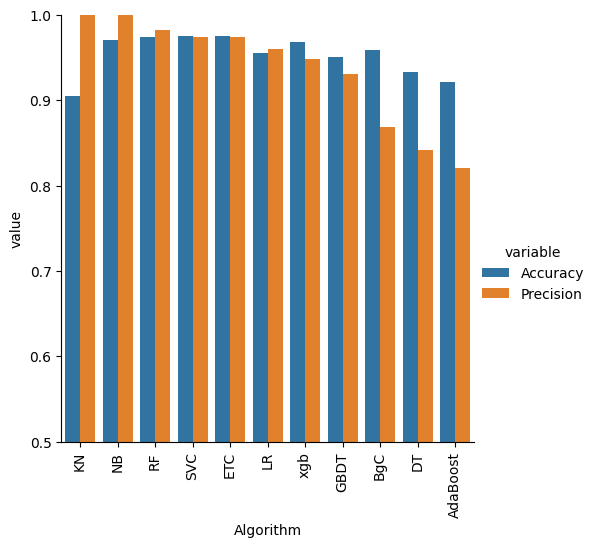

In [128]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
print(performance_df1)
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [129]:
# Model Improvement 
# 1. Change the max_features parameter in the TfidfVectorizer to see if we can improve the accuracy and precision score of our model

In [131]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)
new_df = performance_df.merge(temp_df,on='Algorithm')
new_df_scaled = new_df.merge(temp_df,on='Algorithm')
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)
new_df_scaled.merge(temp_df,on='Algorithm')


,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
6,xgb,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718
7,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,DT,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584


In [132]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [133]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


In [134]:
# Applying stacking, stacking is a technique where we combine the predictions of multiple models to create a new model, which is called the meta-model. The meta-model is trained on the predictions of the base models and the true labels of the training data. The meta-model can be any machine learning algorithm, but in this case we will use Random Forest Classifier as the meta-model.
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [135]:
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9465648854961832


In [136]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))